In [1]:
%%capture
!pip install dask
!pip install contextily

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.animation as animation
import xarray as xr
import glob
import geopandas as gpd
from shapely.geometry import box
import pandas as pd
import contextily as ctx

## Assessing NEX GDDP CMIP6 .nc files

#### Load and inspect 

In [14]:
# Open NetCDF file
hist_pr = xr.open_dataset(r'D:\H2I_lab\Papers\5. DoD_NFW\2. Climate change\Data\Climate change data\GCM\MRI-ESM2-0\precip\historical\pr_day_MRI-ESM2-0_historical_r1i1p1f1_gn_1950.nc')

# Print structure
print(hist_pr)

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 365, lat: 600, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1950-01-01T12:00:00 ... 1950-12-31T12:...
  * lat      (lat) float64 5kB -59.88 -59.62 -59.38 -59.12 ... 89.38 89.62 89.88
  * lon      (lon) float64 12kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    pr       (time, lat, lon) float32 1GB ...
Attributes: (12/22)
    activity:              NEX-GDDP-CMIP6
    contact:               Dr. Rama Nemani: rama.nemani@nasa.gov, Dr. Bridget...
    Conventions:           CF-1.7
    creation_date:         2021-10-04T19:56:19.793647+00:00
    frequency:             day
    institution:           NASA Earth Exchange, NASA Ames Research Center, Mo...
    ...                    ...
    history:               2021-10-04T19:56:19.793647+00:00: install global a...
    disclaimer:            This data is considered provisional and subject to...
    external_variables:    areacella
    cmip6_source_id:       MRI-ES

#### Extract variable data

In [29]:
# Get precipitation variable
precip = hist_pr["pr"]

# Extract time, lat, lon coordinates
time = hist_pr["time"].values
lat = hist_pr["lat"].values
lon = hist_pr["lon"].values

time
# count_time = hist_pr.count
# print(count_time)

array(['1950-01-01T12:00:00.000000000', '1950-01-02T12:00:00.000000000',
       '1950-01-03T12:00:00.000000000', '1950-01-04T12:00:00.000000000',
       '1950-01-05T12:00:00.000000000', '1950-01-06T12:00:00.000000000',
       '1950-01-07T12:00:00.000000000', '1950-01-08T12:00:00.000000000',
       '1950-01-09T12:00:00.000000000', '1950-01-10T12:00:00.000000000',
       '1950-01-11T12:00:00.000000000', '1950-01-12T12:00:00.000000000',
       '1950-01-13T12:00:00.000000000', '1950-01-14T12:00:00.000000000',
       '1950-01-15T12:00:00.000000000', '1950-01-16T12:00:00.000000000',
       '1950-01-17T12:00:00.000000000', '1950-01-18T12:00:00.000000000',
       '1950-01-19T12:00:00.000000000', '1950-01-20T12:00:00.000000000',
       '1950-01-21T12:00:00.000000000', '1950-01-22T12:00:00.000000000',
       '1950-01-23T12:00:00.000000000', '1950-01-24T12:00:00.000000000',
       '1950-01-25T12:00:00.000000000', '1950-01-26T12:00:00.000000000',
       '1950-01-27T12:00:00.000000000', '1950-01-28

#### Visualize a single time step

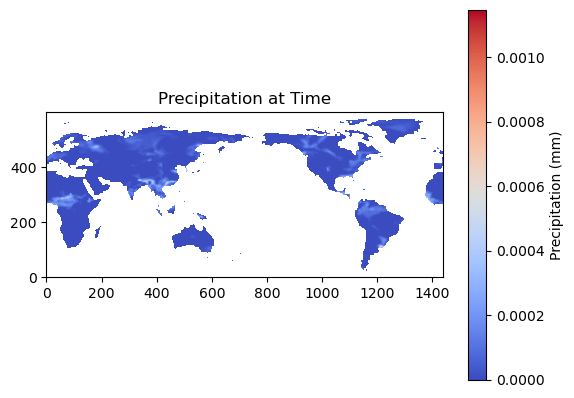

In [39]:
# Select a specific time step (e.g., first time index)
precip_data = precip.isel(time=200)

# Plot Precipitation data
plt.imshow(precip_data, cmap="coolwarm", origin="lower")
plt.colorbar(label="Precipitation (mm)")
plt.title("Precipitation at Time")
plt.show()

#### Combine multiple .nc files

In [44]:
# Define the parameter you want to extract
parameter = "pr"  # Change based on your dataset

# List all NetCDF files in the directory
file_list = sorted(glob.glob(r"D:\H2I_lab\Papers\5. DoD_NFW\2. Climate change\Data\Climate change data\GCM\MRI-ESM2-0\precip\historical\*.nc"))  # Adjust the path

# Open multiple NetCDF files and combine them
ds = xr.open_mfdataset(file_list, combine="by_coords")  # Auto-aligns based on coordinates

# Extract the selected parameter
data_array = ds[parameter]  # Extract the variable

# Convert to NumPy array
data_numpy = data_array.values  # This removes metadata, keeping only raw data

# Save to .npy file
np.save(r"D:\H2I_lab\Papers\5. DoD_NFW\2. Climate change\Data\Climate change data\GCM\MRI-ESM2-0\precip\historical\combined_pr.npy", data_numpy)

print("Combined data saved as 'combined_data.npy'")

ValueError: unrecognized chunk manager dask - must be one of: []

## Preprocessing the NEX GDDP data for SWAT integration

#### Load and inspect xarray data

In [22]:
#Loading the .npy files
data_hist = np.load(r"D:\H2I_lab\Papers\5. DoD_NFW\2. Climate change\Data\Climate change data\GCM\MRI-ESM2-0\precip\historical\dayPrcpUmrb_hist_M01.npy")
# data_ssp = np.load(r"D:\H2I_lab\Papers\5. DoD_NFW\2. Climate change\Data\Climate change data\Model simulated\cesm2\dayPrecipUsSsp370EnsMean.npy")

# print(data_hist)
# print(data_ssp)

# Check shape
print(data_hist.shape)

(10957, 39, 48)


#### Visualizing the data 

In [3]:
#Loading the Lat/Long values
lat = np.load(r"D:\H2I_lab\Papers\5. DoD_NFW\2. Climate change\Data\Climate change data\GCM\MRI-ESM2-0\precip\latsUmrbArr.npy")
long = np.load(r"D:\H2I_lab\Papers\5. DoD_NFW\2. Climate change\Data\Climate change data\GCM\MRI-ESM2-0\precip\lonsUmrbArr.npy")

print(lat)
print(long)
print(lat.shape)
print (long.shape)

[38.375 38.625 38.875 39.125 39.375 39.625 39.875 40.125 40.375 40.625
 40.875 41.125 41.375 41.625 41.875 42.125 42.375 42.625 42.875 43.125
 43.375 43.625 43.875 44.125 44.375 44.625 44.875 45.125 45.375 45.625
 45.875 46.125 46.375 46.625 46.875 47.125 47.375 47.625 47.875]
[262.375 262.625 262.875 263.125 263.375 263.625 263.875 264.125 264.375
 264.625 264.875 265.125 265.375 265.625 265.875 266.125 266.375 266.625
 266.875 267.125 267.375 267.625 267.875 268.125 268.375 268.625 268.875
 269.125 269.375 269.625 269.875 270.125 270.375 270.625 270.875 271.125
 271.375 271.625 271.875 272.125 272.375 272.625 272.875 273.125 273.375
 273.625 273.875 274.125]
(39,)
(48,)


In [ ]:
#Plotting 1D array (the lat/long data) 
# plt.plot(lat)
# plt.title("1D NumPy Array Visualization")
# plt.show()

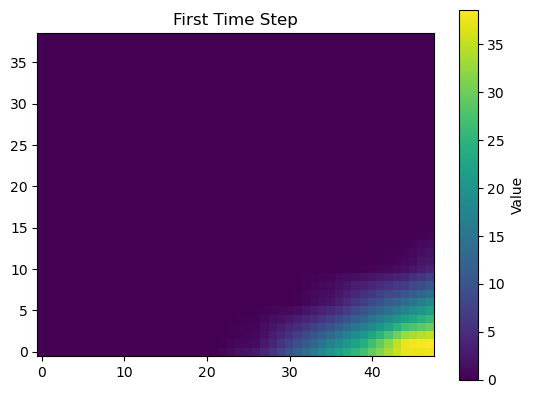

In [32]:
# Plotting the 3D array
# plt.imshow(data_hist)  # Assuming it’s an image
# plt.imshow(data_hist, cmap="viridis")  # Change colormap as needed
# plt.title("3D NumPy Array (RGB) Visualization")
# plt.colorbar()
# plt.show()

#Plotting the 3d array data for a single timestep 
# Select the first time step (t=0)
data_2d = data_hist[3000, :, :] # Shape (39, 48)

# Plot the selected time step
plt.imshow(data_2d, cmap="viridis", origin="lower")
plt.colorbar(label="Value")
plt.title("First Time Step")
plt.show()

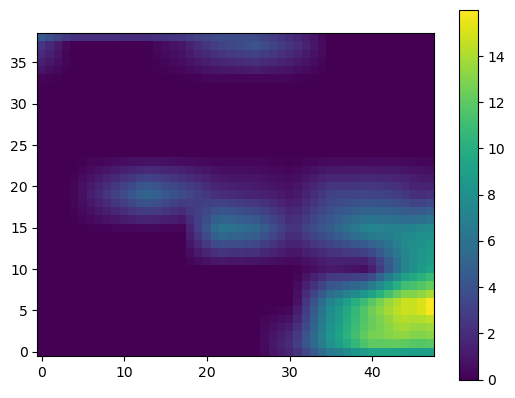

In [72]:
#Creating an animation of the entire dataset
fig, ax = plt.subplots()
img = ax.imshow(data_hist[2000, :, :], cmap="viridis", origin="lower")
plt.colorbar(img)

def update(frame):
    img.set_data(data_hist[frame, :, :])
    ax.set_title(f"Time Step: {frame}")
    return img,

ani = animation.FuncAnimation(fig, update, frames=100, interval=100)
plt.show()

#### Generating meshgrid from the observed point data

In [21]:
#Load the test region observed point shapefile
gdf = gpd.read_file(r"D:\H2I_lab\Papers\5. DoD_NFW\2. Climate change\Data\Shapefiles\Observed_data_clp.shp")

print(gdf.head())

      ID    NAME      LAT     LONG  ELEVATION                    geometry
0  26455  p33871  38.7235 -97.2654        396  POINT (-97.26540 38.72350)
1  26456  p33872  38.7247 -97.1493        393  POINT (-97.14930 38.72470)
2  26457  p33873  38.7257 -97.0332        405  POINT (-97.03320 38.72570)
3  26458  p33874  38.7266 -96.9171        419  POINT (-96.91710 38.72660)
4  26459  p33875  38.7274 -96.8010        455  POINT (-96.80100 38.72740)


In [27]:
#Extract point coordinates
x_coords = gdf.geometry.x
y_coords = gdf.geometry.y

print(x_coords)
print(y_coords)
print(gdf.crs)

0      -97.2654
1      -97.1493
2      -97.0332
3      -96.9171
4      -96.8010
         ...   
8423   -90.9576
8424   -90.8256
8425   -90.6935
8426   -90.5539
8427   -90.4217
Length: 8428, dtype: float64
0       38.7235
1       38.7247
2       38.7257
3       38.7266
4       38.7274
         ...   
8423    47.6953
8424    47.6904
8425    47.6854
8426    47.7707
8427    47.7655
Length: 8428, dtype: float64
EPSG:4326


In [14]:
# np.sort(x_coords)

np.sort(y_coords)

array([38.6912, 38.6913, 38.6929, ..., 47.7707, 47.7725, 47.7743])

In [15]:
np.diff(np.sort(x_coords))

array([0.0018, 0.0017, 0.0018, ..., 0.0003, 0.0015, 0.0016])

In [23]:
# Define grid resolution based on the minimum spacing between points
dx = np.min(np.diff(np.sort(x_coords)))  # Grid spacing in x-direction
dy = np.min(np.diff(np.sort(y_coords)))  # Grid spacing in y-direction

# print(dx)
# print(dy)
print(f"Grid Cell Size: dx={dx}, dy={dy}")

Grid Cell Size: dx=0.0, dy=0.0


In [25]:
# Define grid bounds
xmin, xmax = x_coords.min(), x_coords.max()
ymin, ymax = y_coords.min(), y_coords.max()

print(ymin, ymax)
print(xmin,xmax)

38.69120000000004 47.77430000000004
-97.35829999999999 -85.90099999999995


In [12]:
# Generate grid points
x_grid = np.arange(xmin, xmax + dx, dx)
y_grid = np.arange(ymin, ymax + dy, dy)

# Create meshgrid
x_mesh, y_mesh = np.meshgrid(x_grid, y_grid)

C:\Users\axk5551\AppData\Local\Temp\ipykernel_19108\1859735910.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  x_grid = np.arange(xmin, xmax + dx, dx)


ValueError: Maximum allowed size exceeded

In [26]:
# Generate grid boundaries ensuring points are at the center
x_grid = np.arange(xmin - dx / 2, xmax + dx, dx)
y_grid = np.arange(ymin - dy / 2, ymax + dy, dy)

# Create fishnet grid cells
fishnet = []
for x in x_grid:
    for y in y_grid:
        cell = box(x - dx / 2, y - dy / 2, x + dx / 2, y + dy / 2)  # Create a square polygon
        fishnet.append(cell)

C:\Users\axk5551\AppData\Local\Temp\ipykernel_19108\2186956723.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  x_grid = np.arange(xmin - dx / 2, xmax + dx, dx)


ValueError: Maximum allowed size exceeded

In [34]:
# Define fixed grid cell size (in degrees)
cell_size = 0.1  # Approx. 10 km

# Define grid extent with a small buffer
buffer = cell_size  # Add a buffer to avoid cutting points at edges
xmin, xmax = x_coords.min() - buffer, x_coords.max() + buffer
ymin, ymax = y_coords.min() - buffer, y_coords.max() + buffer

In [35]:
# Generate grid coordinates
x_grid = np.arange(xmin, xmax, cell_size)
y_grid = np.arange(ymin, ymax, cell_size)

# Create grid cells centered on the points
fishnet = []
for x in x_grid:
    for y in y_grid:
        # Create a box (cell) with the point at the center
        cell = box(x - cell_size / 2, y - cell_size / 2, 
                   x + cell_size / 2, y + cell_size / 2)
        fishnet.append(cell)

In [36]:
# Convert to GeoDataFrame
fishnet_gdf = gpd.GeoDataFrame(geometry=fishnet, crs=gdf.crs)

In [37]:
# Check the fishnet size
print(f"Generated {len(fishnet)} grid cells.")

Generated 10881 grid cells.


In [38]:
fishnet_gdf.to_file(r"D:\H2I_lab\Papers\5. DoD_NFW\2. Climate change\Data\Shapefiles\fishnet_grid_10km.shp")
print("Fishnet grid saved as 'fishnet_grid_10km.shp'")

Fishnet grid saved as 'fishnet_grid_10km.shp'


#### Regridding the xarray dataset from coarse (25 km) to fine (10 km) resolution

In [3]:
# Load the .npy array dataset
data_hist = np.load(r"D:\Phd Research\Test\dayPrcpUmrb_hist_M01.npy")

# print(data_hist)

# Check shape
print(data_hist.shape)

(10957, 39, 48)


In [7]:
# Define the lat and long
lat = np.load(r"D:\H2I_lab\Papers\5. DoD_NFW\2. Climate change\Data\Climate change data\GCM\MRI-ESM2-0\precip\latsUmrbArr.npy")
lon = np.load(r"D:\H2I_lab\Papers\5. DoD_NFW\2. Climate change\Data\Climate change data\GCM\MRI-ESM2-0\precip\lonsUmrbArr.npy")

print(lat)
print(long)
print(lat.shape)
print (long.shape)

[38.375 38.625 38.875 39.125 39.375 39.625 39.875 40.125 40.375 40.625
 40.875 41.125 41.375 41.625 41.875 42.125 42.375 42.625 42.875 43.125
 43.375 43.625 43.875 44.125 44.375 44.625 44.875 45.125 45.375 45.625
 45.875 46.125 46.375 46.625 46.875 47.125 47.375 47.625 47.875]
[262.375 262.625 262.875 263.125 263.375 263.625 263.875 264.125 264.375
 264.625 264.875 265.125 265.375 265.625 265.875 266.125 266.375 266.625
 266.875 267.125 267.375 267.625 267.875 268.125 268.375 268.625 268.875
 269.125 269.375 269.625 269.875 270.125 270.375 270.625 270.875 271.125
 271.375 271.625 271.875 272.125 272.375 272.625 272.875 273.125 273.375
 273.625 273.875 274.125]
(39,)
(48,)


In [11]:
# Access the data along time dimension of the .npy array
start_date = "1985-01-01"
time = pd.date_range(start=start_date, periods=data_hist.shape[0], freq="D")

print(time)
# print(time.shape)

DatetimeIndex(['1985-01-01', '1985-01-02', '1985-01-03', '1985-01-04',
               '1985-01-05', '1985-01-06', '1985-01-07', '1985-01-08',
               '1985-01-09', '1985-01-10',
               ...
               '2014-12-22', '2014-12-23', '2014-12-24', '2014-12-25',
               '2014-12-26', '2014-12-27', '2014-12-28', '2014-12-29',
               '2014-12-30', '2014-12-31'],
              dtype='datetime64[ns]', length=10957, freq='D')


In [12]:
# Create an xarray DataArray
ds = xr.DataArray(
    data_hist, 
    coords={"time": time, "lat": lat, "lon":lon},
    dims=["time", "lat", "lon"],
    name="precip"
)

ds

<xarray.DataArray 'precip' (time: 10957, lat: 39, lon: 48)> Size: 164MB
array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.2614668 ,
         0.53118767, 0.80092181],
        [0.        , 0.        , 0.        , ..., 0.33228719,
         0.67809366, 1.03072098],
        [0.        , 0.        , 0.        , ..., 0.94215151,
         1.27001793, 1.62641129]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
...
        [0.        , 0.        , 0.        , ..., 2.67753244,
         2.50537548, 2.30384315],
        [0.        , 0.        , 0.        , ..., 2.62241901,
         2.45343183, 2.26127068],
        [0.        , 0.        , 0.        , ..., 2.60954237,
         2.44146357, 2.27170913]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 3.20300924,
         3.08801068, 2.93840974],
        [0.        , 0.        , 0.        , ..., 2.99749745,
         2.90340597, 2.785251  ],
        [0.        , 0.        , 0.        , ..., 2.77932573,
         2.69573259, 2.61739176]]])
Coordinates:
  * time     (time) datetime64[ns] 88kB 1985-01-01 1985-01-02 ... 2014-12-31
  * lat      (lat) float64 312B 38.38 38.62 38.88 39.12 ... 47.38 47.62 47.88
  * lon      (lon) float64 384B 262.4 262.6 262.9 263.1 ... 273.6 273.9 274.1

In [13]:
# Define new higher-resolution latitude and longitude grids (10 km resolution)
# new_lat = np.linspace(ds.lat.min(), ds.lat.max(), data_hist.shape[1] * 2.5)  # Increase grid density
# new_lon = np.linspace(ds.lon.min(), ds.lon.max(), data_hist.shape[2] * 2.5)  # Increase grid density

new_lat = np.linspace(ds.lat.min(), ds.lat.max(), int(data_hist.shape[1] * 2.5))
new_lon = np.linspace(ds.lon.min(), ds.lon.max(), int(data_hist.shape[2] * 2.5))


In [14]:
# Perform interpolation to finer resolution (10 km)
ds_regridded = ds.interp(lat=new_lat, lon=new_lon, method="linear")

In [17]:
# Display summary of the regridded DataArray
ds_regridded
# ds_regridded.shape

<xarray.DataArray 'precip' (time: 10957, lat: 97, lon: 120)> Size: 1GB
array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.87565742,
         1.01524027, 1.15482313],
        [0.        , 0.        , 0.        , ..., 1.11027395,
         1.25044558, 1.39061721],
        [0.        , 0.        , 0.        , ..., 1.34489048,
         1.48565089, 1.62641129]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
...
        [0.        , 0.        , 0.        , ..., 2.41154914,
         2.33749725, 2.26344535],
        [0.        , 0.        , 0.        , ..., 2.40867501,
         2.33812612, 2.26757724],
        [0.        , 0.        , 0.        , ..., 2.40580088,
         2.338755  , 2.27170913]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 2.83706078,
         2.79367055, 2.75028032],
        [0.        , 0.        , 0.        , ..., 2.7581676 ,
         2.72100182, 2.68383604],
        [0.        , 0.        , 0.        , ..., 2.67927443,
         2.64833309, 2.61739176]]])
Coordinates:
  * time     (time) datetime64[ns] 88kB 1985-01-01 1985-01-02 ... 2014-12-31
  * lat      (lat) float64 776B 38.38 38.47 38.57 38.67 ... 47.68 47.78 47.88
  * lon      (lon) float64 960B 262.4 262.5 262.6 262.7 ... 273.9 274.0 274.1

In [16]:
ds_regridded.to_netcdf(r"D:\H2I_lab\Papers\5. DoD_NFW\2. Climate change\Data\Climate change data\GCM\MRI-ESM2-0\precip\historical\dayPrcpUmrb_hist_regridded.nc")

In [18]:
# Open NetCDF file
hist_pr_regrid = xr.open_dataset(r"D:\H2I_lab\Papers\5. DoD_NFW\2. Climate change\Data\Climate change data\GCM\MRI-ESM2-0\precip\historical\dayPrcpUmrb_hist_regridded.nc")

# Print structure
print(hist_pr_regrid)

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 10957, lat: 97, lon: 120)
Coordinates:
  * time     (time) datetime64[ns] 88kB 1985-01-01 1985-01-02 ... 2014-12-31
  * lat      (lat) float64 776B 38.38 38.47 38.57 38.67 ... 47.68 47.78 47.88
  * lon      (lon) float64 960B 262.4 262.5 262.6 262.7 ... 273.9 274.0 274.1
Data variables:
    precip   (time, lat, lon) float64 1GB ...


In [21]:
# Get precipitation variable
precip = hist_pr_regrid["precip"]

# Extract time, lat, lon coordinates
time = hist_pr_regrid["time"].values
lat = hist_pr_regrid["lat"].values
lon = hist_pr_regrid["lon"].values

# time
# count_time = hist_pr.count
# print(count_time)

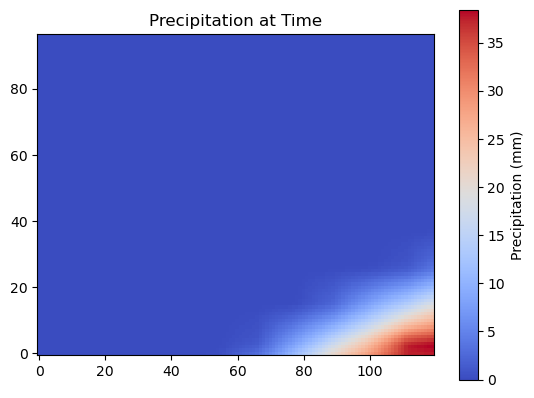

In [22]:
# Select a specific time step (e.g., first time index)
precip_data = precip.isel(time=3000)

# Plot Precipitation data
plt.imshow(precip_data, cmap="coolwarm", origin="lower")
plt.colorbar(label="Precipitation (mm)")
plt.title("Precipitation at Time")
plt.show()

#### Observed point dataset

In [33]:
# Load the shapefile
gdf = gpd.read_file(r"D:\H2I_lab\Papers\5. DoD_NFW\2. Climate change\Data\Shapefiles\Observed_data_clp.shp")

print(gdf.head())
print(gdf.crs)
print(len(gdf))

      ID    NAME      LAT     LONG  ELEVATION                    geometry
0  26455  p33871  38.7235 -97.2654        396  POINT (-97.26540 38.72350)
1  26456  p33872  38.7247 -97.1493        393  POINT (-97.14930 38.72470)
2  26457  p33873  38.7257 -97.0332        405  POINT (-97.03320 38.72570)
3  26458  p33874  38.7266 -96.9171        419  POINT (-96.91710 38.72660)
4  26459  p33875  38.7274 -96.8010        455  POINT (-96.80100 38.72740)
EPSG:4326
8428


In [27]:
# Extract point coordinates
obs_lons = gdf.geometry.x
obs_lats = gdf.geometry.y

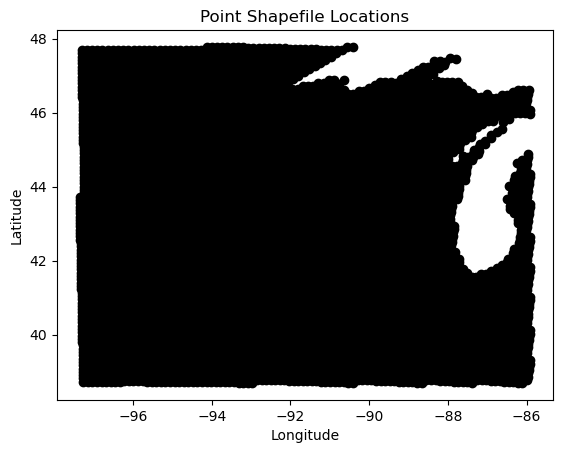

In [28]:
# Scatter plot points
plt.scatter(obs_lons, obs_lats, color="black", marker="o")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Point Shapefile Locations")
# ctx.add_basemap(gdf, source=ctx.providers.OpenStreetMap.Mapnik)  # Adds a terrain basemap
plt.show()

#### Extracting values at observation points

In [31]:
# Extract values at observed data points
obs_values = ds_regridded.sel(lat=xr.DataArray(obs_lats, dims="points"), lon=xr.DataArray(obs_lons, dims="points"), method="nearest")

print(len(obs_values))

10957


In [30]:
# Convert to Pandas DataFrame for saving
obs_df = gdf.copy()
obs_df["Interpolated_Value"] = obs_values.values

ValueError: Length of values (10957) does not match length of index (8428)

In [ ]:
# Save the interpolated data
obs_df.to_csv("regridded_observed_data.csv", index=False)

In [4]:
import numpy as np

# Load the dataset
data_hist = np.load(r"D:\Phd Research\Test\dayPrcpUmrb_hist_M01.npy")

# Print basic information
print("Data type:", data_hist.dtype)
print("Shape of the array:", data_hist.shape)

# Print sample data (first 5 values along axis 0)
print("Sample data:\n", data_hist[:5])


Data type: float64
Shape of the array: (10957, 39, 48)
Sample data:
 [[[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  ...
  [0.         0.         0.         ... 0.2614668  0.53118767 0.80092181]
  [0.         0.         0.         ... 0.33228719 0.67809366 1.03072098]
  [0.         0.         0.         ... 0.94215151 1.27001793 1.62641129]]

 [[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  ...
  [0.         0.         0.         ... 0.64298935 0.91244853 1.17776987]
  [0.         0.         0.         ... 0.58946847 0.886673   1.18759249]
  [0.         0.         0.         ... 0.53045731 0.84889589 1.193748  ]]

 [[0.         0.         0.

In [9]:
import numpy as np

# Load the .npy file
data = np.load(r"D:\Phd Research\Test\dayPrcpUmrb_hist_M01.npy", allow_pickle=True)

# Check if it's a dictionary or multiple arrays
print(type(data))

if isinstance(data, dict):  # If stored as a dictionary
    print(data.keys())  # Print keys to see what's inside


<class 'numpy.ndarray'>


In [11]:
import numpy as np

file_path = r"D:\Phd Research\Test\dayPrcpUmrb_hist_M01.npy"
data = np.load(file_path)

print("Data Type:", type(data))
print("Array Shape:", data.shape)
print("Data Type of Elements:", data.dtype)


Data Type: <class 'numpy.ndarray'>
Array Shape: (10957, 39, 48)
Data Type of Elements: float64


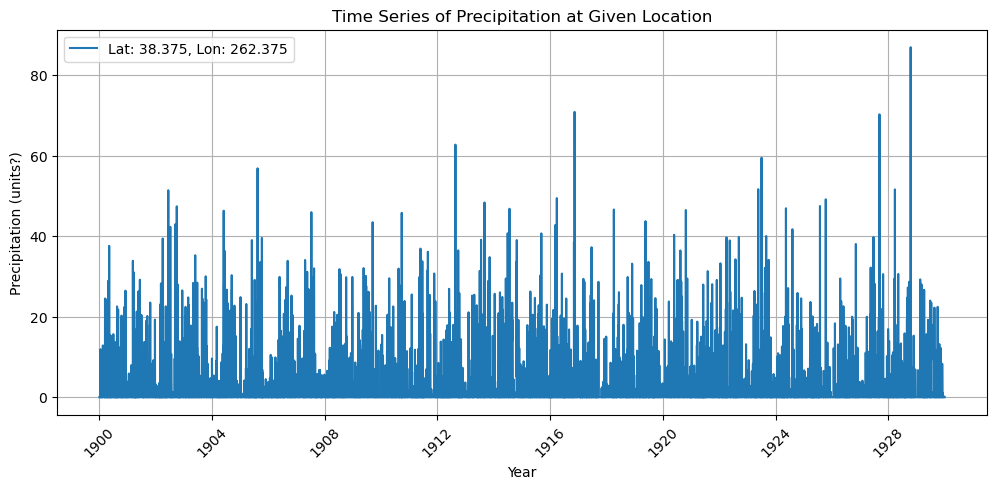

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import datetime

# Load data
data = np.load(r"D:\Phd Research\Test\dayPrcpUmrb_hist_M01.npy")  # Shape: (10957, 39, 48)
latitudes = np.load(r"D:\Phd Research\Test\Arushi\latsUmrbArr.npy")  # Shape: (39,)
longitudes = np.load(r"D:\Phd Research\Test\Arushi\lonsUmrbArr.npy")  # Shape: (48,)

# Given lat/lon
target_lat = 34.5  # Replace with actual latitude
target_lon = -97.2  # Replace with actual longitude

# Find nearest index for given lat/lon
lat_idx = np.argmin(np.abs(latitudes - target_lat))
lon_idx = np.argmin(np.abs(longitudes - target_lon))

# Extract the time series
time_series = data[:, lat_idx, lon_idx]

# Generate time array assuming daily data starting from January 1, 1900
start_date = datetime.datetime(1900, 1, 1)
dates = [start_date + datetime.timedelta(days=i) for i in range(len(time_series))]

# Plot the time series
plt.figure(figsize=(12, 5))
plt.plot(dates, time_series, label=f"Lat: {latitudes[lat_idx]}, Lon: {longitudes[lon_idx]}")

# Format x-axis
plt.xlabel("Year")
plt.ylabel("Precipitation (units?)")  # Replace with actual units
plt.title("Time Series of Precipitation at Given Location")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)  # Rotate labels for better readability
plt.show()
